In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier 
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
column_names = [
    'pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
    'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev',
    'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco',
    'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
    'attack', 'category', 'subcategory'
]

# Load the CSV file with the specified column names
main_data = pd.read_csv("data_12.csv", header=None, names=column_names)

# Display the first few rows of the data to verify
print(main_data.head())

   pkSeqID         stime flgs proto            saddr   sport          daddr  \
0  9000001  1.528083e+09  e s   tcp  192.168.100.150  5712.0  192.168.100.6   
1  9000002  1.528083e+09  e s   tcp  192.168.100.150  5713.0  192.168.100.6   
2  9000003  1.528083e+09  e s   tcp  192.168.100.150  5594.0  192.168.100.6   
3  9000004  1.528083e+09  e s   tcp  192.168.100.150  5595.0  192.168.100.6   
4  9000005  1.528083e+09  e s   tcp  192.168.100.150  5598.0  192.168.100.6   

   dport  pkts  bytes  ... spkts  dpkts  sbytes  dbytes      rate     srate  \
0   80.0     4    616  ...     4      0     616       0  0.050914  0.050914   
1   80.0     4    616  ...     4      0     616       0  0.050914  0.050914   
2   80.0     6    736  ...     4      2     616     120  0.084802  0.050914   
3   80.0     6    736  ...     4      2     616     120  0.084802  0.050914   
4   80.0     6    736  ...     4      2     616     120  0.084802  0.050914   

      drate  attack  category  subcategory  
0  0.

In [26]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   pkSeqID      1000000 non-null  int64  
 1   stime        1000000 non-null  float64
 2   flgs         1000000 non-null  object 
 3   proto        1000000 non-null  object 
 4   saddr        1000000 non-null  object 
 5   sport        999971 non-null   float64
 6   daddr        1000000 non-null  object 
 7   dport        999971 non-null   float64
 8   pkts         1000000 non-null  int64  
 9   bytes        1000000 non-null  int64  
 10  state        1000000 non-null  object 
 11  ltime        1000000 non-null  float64
 12  seq          1000000 non-null  int64  
 13  dur          1000000 non-null  float64
 14  mean         1000000 non-null  float64
 15  stddev       1000000 non-null  float64
 16  smac         0 non-null        float64
 17  dmac         0 non-null        float64
 18  sum

In [27]:

main_data2 = pd.read_csv("data_13.csv",header=None, names=column_names)
main_data2.head()

,pkSeqID,stime,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,15000001,1.528085e+09,e,udp,192.168.100.149,31093,192.168.100.5,80,8,480,...,8,0,480,0,0.281715,0.281715,0.0,1,DoS,UDP
1,15000002,1.528085e+09,e,udp,192.168.100.149,31094,192.168.100.5,80,8,480,...,8,0,480,0,0.281715,0.281715,0.0,1,DoS,UDP
2,15000003,1.528085e+09,e,udp,192.168.100.149,31095,192.168.100.5,80,8,480,...,8,0,480,0,0.281715,0.281715,0.0,1,DoS,UDP
3,15000004,1.528085e+09,e,udp,192.168.100.149,31096,192.168.100.5,80,8,480,...,8,0,480,0,0.281715,0.281715,0.0,1,DoS,UDP
4,15000005,1.528085e+09,e,udp,192.168.100.149,31097,192.168.100.5,80,8,480,...,8,0,480,0,0.281715,0.281715,0.0,1,DoS,UDP


In [28]:
main_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 35 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   pkSeqID      1000000 non-null  int64  
 1   stime        1000000 non-null  float64
 2   flgs         1000000 non-null  object 
 3   proto        1000000 non-null  object 
 4   saddr        1000000 non-null  object 
 5   sport        999972 non-null   object 
 6   daddr        1000000 non-null  object 
 7   dport        999972 non-null   object 
 8   pkts         1000000 non-null  int64  
 9   bytes        1000000 non-null  int64  
 10  state        1000000 non-null  object 
 11  ltime        1000000 non-null  float64
 12  seq          1000000 non-null  int64  
 13  dur          1000000 non-null  float64
 14  mean         1000000 non-null  float64
 15  stddev       1000000 non-null  float64
 16  smac         0 non-null        float64
 17  dmac         0 non-null        float64
 18  sum

In [29]:
data = pd.concat([main_data, main_data2], ignore_index=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 35 columns):
 #   Column       Dtype  
---  ------       -----  
 0   pkSeqID      int64  
 1   stime        float64
 2   flgs         object 
 3   proto        object 
 4   saddr        object 
 5   sport        object 
 6   daddr        object 
 7   dport        object 
 8   pkts         int64  
 9   bytes        int64  
 10  state        object 
 11  ltime        float64
 12  seq          int64  
 13  dur          float64
 14  mean         float64
 15  stddev       float64
 16  smac         float64
 17  dmac         float64
 18  sum          float64
 19  min          float64
 20  max          float64
 21  soui         float64
 22  doui         float64
 23  sco          float64
 24  dco          float64
 25  spkts        int64  
 26  dpkts        int64  
 27  sbytes       int64  
 28  dbytes       int64  
 29  rate         float64
 30  srate        float64
 31  drate        float64
 32

In [30]:
data.describe()

,pkSeqID,stime,pkts,bytes,ltime,seq,dur,mean,stddev,smac,...,sco,dco,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,0.0,...,0.0,0.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.250000e+07,1.528084e+09,6.720364e+00,6.412330e+02,1.528084e+09,1.307157e+05,3.068010e+01,1.664165e+00,4.820878e-01,NaN,...,NaN,NaN,6.277752e+00,4.426115e-01,5.963342e+02,4.489873e+01,2.562086e-01,2.177961e-01,6.761563e-03,9.999710e-01
std,3.013858e+06,1.088174e+03,2.249116e+01,1.961901e+04,1.077306e+03,7.321646e+04,1.435798e+01,1.718289e+00,7.321619e-01,NaN,...,NaN,NaN,1.631127e+01,8.999874e+00,1.246071e+04,8.799556e+03,3.228058e+01,4.675304e-01,2.446201e-01,5.385088e-03
min,9.000001e+06,1.528083e+09,1.000000e+00,6.000000e+01,1.528083e+09,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,...,NaN,NaN,1.000000e+00,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.500001e+06,1.528083e+09,4.000000e+00,4.200000e+02,1.528083e+09,6.815300e+04,2.269841e+01,8.790750e-03,0.000000e+00,NaN,...,NaN,NaN,3.000000e+00,0.000000e+00,4.200000e+02,0.000000e+00,8.655400e-02,7.190000e-02,0.000000e+00,1.000000e+00
50%,1.250000e+07,1.528084e+09,6.000000e+00,5.220000e+02,1.528084e+09,1.306530e+05,2.737759e+01,9.815750e-01,1.935900e-02,NaN,...,NaN,NaN,6.000000e+00,0.000000e+00,4.620000e+02,0.000000e+00,1.946870e-01,1.363270e-01,0.000000e+00,1.000000e+00
75%,1.550000e+07,1.528085e+09,8.000000e+00,7.700000e+02,1.528085e+09,1.931530e+05,4.177692e+01,3.502390e+00,6.554663e-01,NaN,...,NaN,NaN,7.000000e+00,0.000000e+00,6.420000e+02,0.000000e+00,2.769370e-01,2.769370e-01,0.000000e+00,1.000000e+00
max,1.600000e+07,1.528085e+09,9.999000e+03,9.743662e+06,1.528085e+09,2.621660e+05,6.254704e+01,4.999216e+00,2.403319e+00,NaN,...,NaN,NaN,6.600000e+03,5.000000e+03,4.799763e+06,5.029033e+06,4.545455e+04,2.099613e+02,1.262626e+02,1.000000e+00


In [31]:
data["proto"].value_counts()

proto
tcp     999977
udp     999952
arp         57
icmp        14
Name: count, dtype: int64

In [32]:
data["saddr"].value_counts()

saddr
192.168.100.149    514893
192.168.100.150    500540
192.168.100.148    498813
192.168.100.147    485155
192.168.100.6         215
192.168.100.3         176
192.168.100.5          96
192.168.100.7          87
192.168.100.46         17
192.168.100.55          4
192.168.100.4           2
192.168.100.1           2
Name: count, dtype: int64

In [33]:
data["sport"].value_counts()

sport
80.0       542
12778.0     32
12720.0     32
12719.0     32
12718.0     32
          ... 
4679         1
4680         1
4681         1
4682         1
48261        1
Name: count, Length: 127318, dtype: int64

In [34]:
data["daddr"].value_counts()

daddr
192.168.100.6      513459
192.168.100.7      504743
192.168.100.5      495642
192.168.100.3      485594
192.168.100.150       209
192.168.100.147       163
192.168.100.148        89
192.168.100.149        83
52.64.239.193           7
172.217.25.170          3
192.168.100.55          2
192.168.100.1           2
91.189.89.199           1
192.168.100.4           1
192.168.100.46          1
116.206.83.243          1
Name: count, dtype: int64

In [35]:
data["dport"].value_counts()

dport
80.0       1835602
80          163797
0x5000          14
8883.0           5
0.0              3
            ...   
26922.0          1
26919.0          1
26918.0          1
26915.0          1
32309.0          1
Name: count, Length: 517, dtype: int64

In [36]:
data["category"].value_counts()

category
DoS       1999942
Normal         58
Name: count, dtype: int64

In [37]:
data["attack"].value_counts()

attack
1    1999942
0         58
Name: count, dtype: int64

In [38]:
data["subcategory"].value_counts()

subcategory
UDP       999972
TCP       999970
Normal        58
Name: count, dtype: int64

In [22]:
ten_best_features = data[['seq','stddev','N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP',
       'drate', 'srate', 'max']]
target_features = data[['attack','category','subcategory']]

KeyError: "['N_IN_Conn_P_SrcIP', 'state_number', 'N_IN_Conn_P_DstIP'] not in index"

In [23]:
data.columns

Index(['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport',
       'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev',
       'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco',
       'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate',
       'attack', 'category', 'subcategory '],
      dtype='object')

In [41]:
# Create a new feature tracking the number of packets sent by a source IP
src_ip_counts = data['saddr'].value_counts()
data['N_IN_Conn_P_SrcIP'] = data['saddr'].map(src_ip_counts)

# You can also create a similar feature for destination IP addresses
dst_ip_counts = data['daddr'].value_counts()
data['N_IN_Conn_P_DstIP'] = data['daddr'].map(dst_ip_counts)

# For state, you could consider numeric encoding or one-hot encoding if needed
data['state_number'] = data['state'].astype('category').cat.codes


In [42]:
ten_best_features = data[['seq','stddev','N_IN_Conn_P_SrcIP', 'min', 'state_number', 'mean', 'N_IN_Conn_P_DstIP',
       'drate', 'srate', 'max']]
target_features = data[['attack','category','subcategory']]

In [43]:
le = LabelEncoder()
target_features['category'] = le.fit_transform(target_features['category'])
target_features['subcategory'] = le.fit_transform(target_features['subcategory'])

target_features.head()

,attack,category,subcategory
0,1,0,1
1,1,0,1
2,1,0,1
3,1,0,1
4,1,0,1


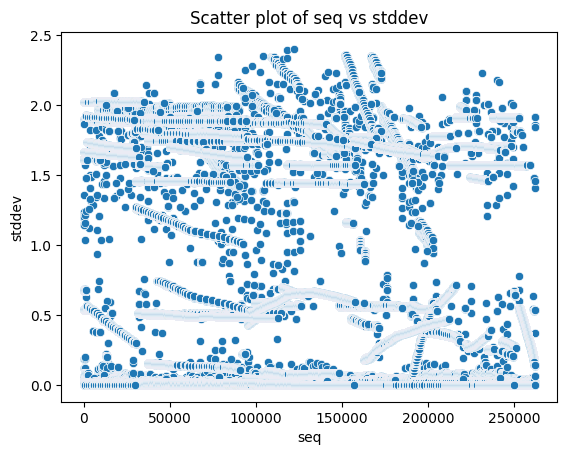

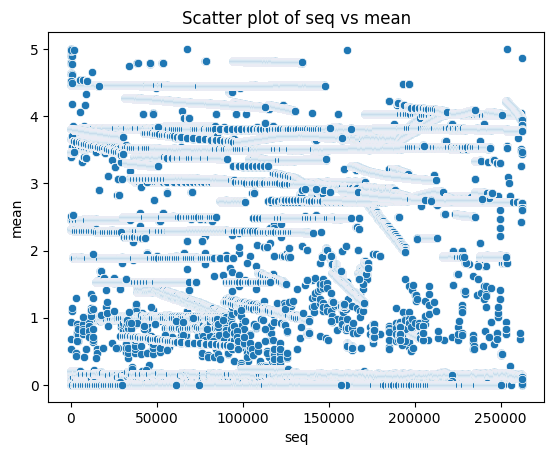

In [44]:
# Scatter plot for two features
sns.scatterplot(data=data, x='seq', y='stddev')
plt.title('Scatter plot of seq vs stddev')
plt.show()

# Another scatter plot for two features (for example, seq vs mean)
sns.scatterplot(data=data, x='seq', y='mean')
plt.title('Scatter plot of seq vs mean')
plt.show()


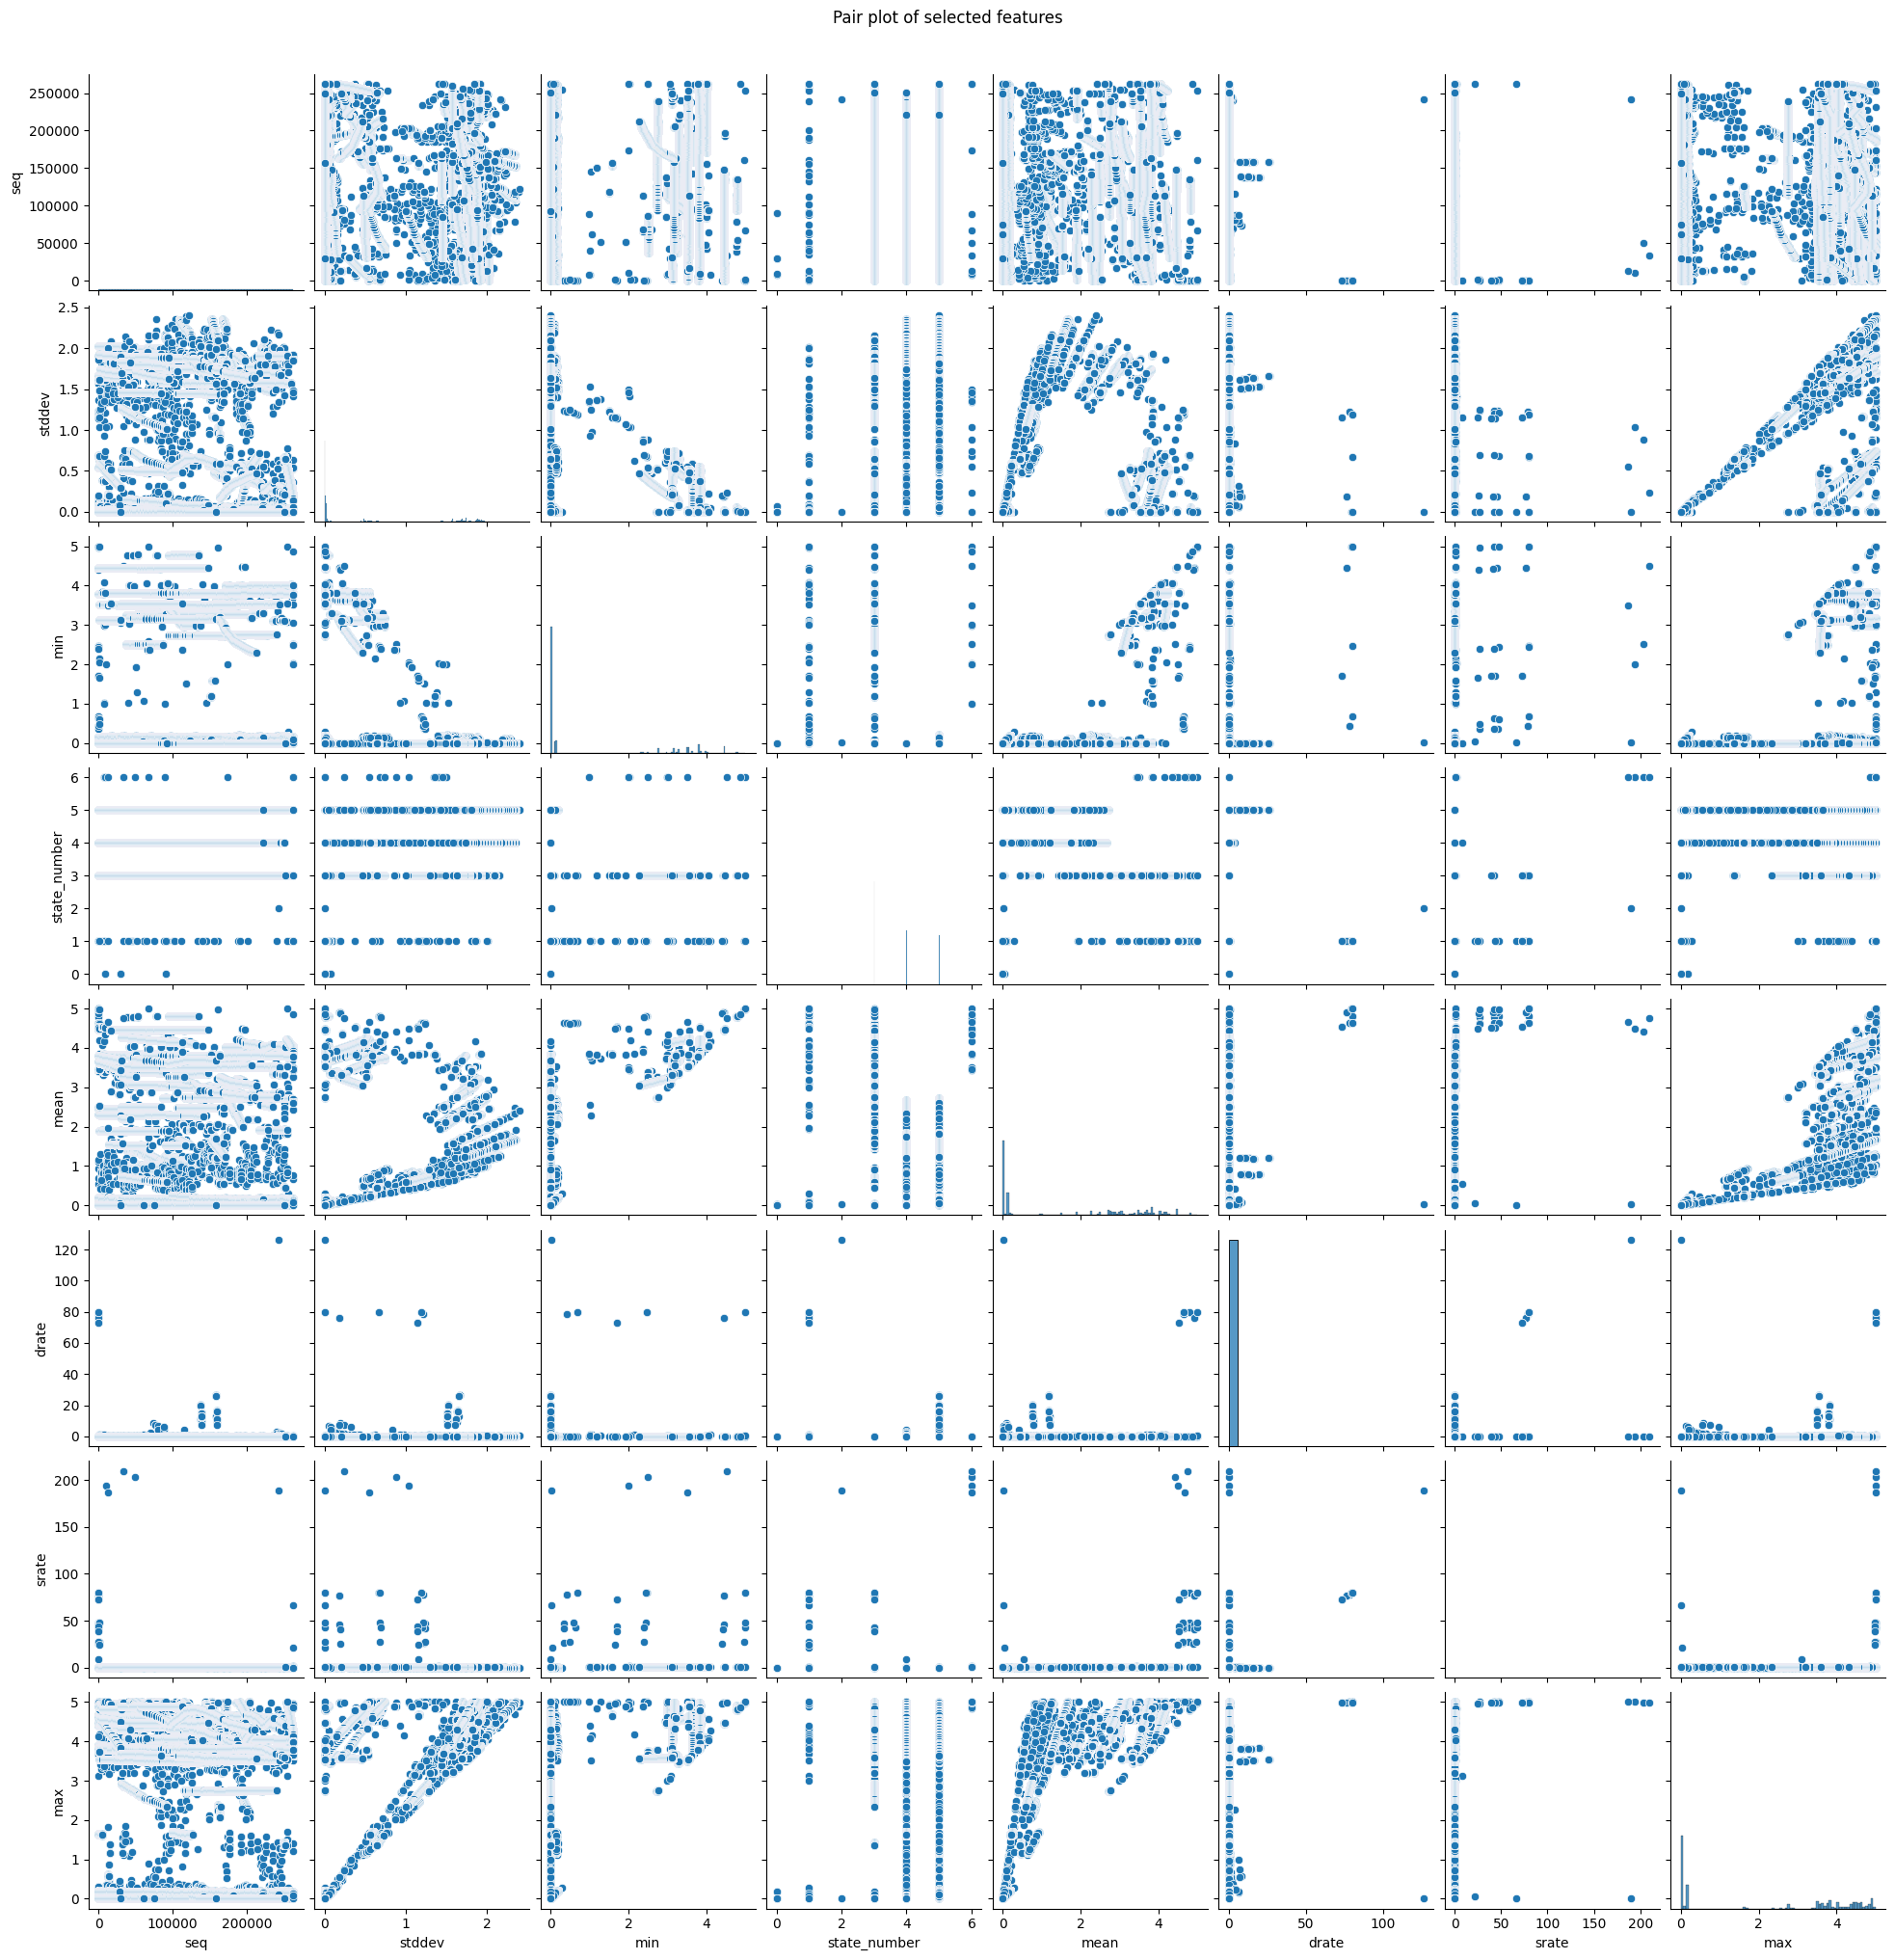

In [45]:
# Pair plot for the ten best features
pair_plot_data = data[['seq', 'stddev', 'min', 'state_number', 'mean', 'drate', 'srate', 'max']]
sns.pairplot(pair_plot_data)
plt.suptitle('Pair plot of selected features', y=1.02)
plt.show()


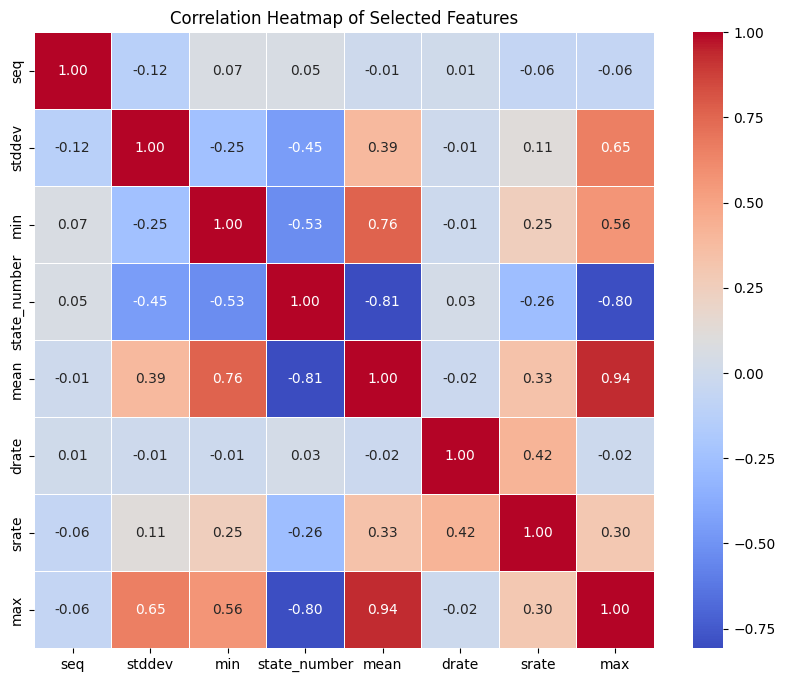

In [46]:
# Compute correlation matrix
corr_matrix = data[['seq', 'stddev', 'min', 'state_number', 'mean', 'drate', 'srate', 'max']].corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Features')
plt.show()


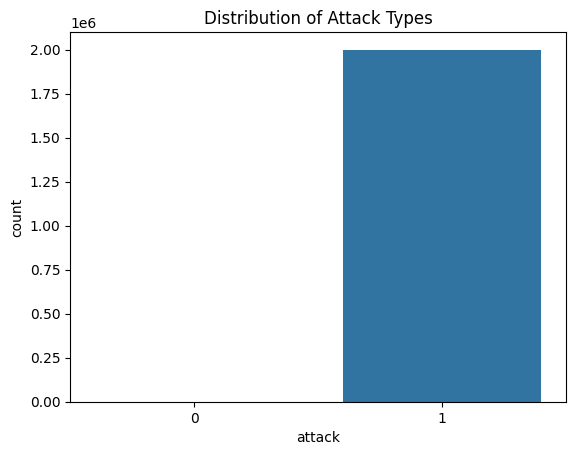

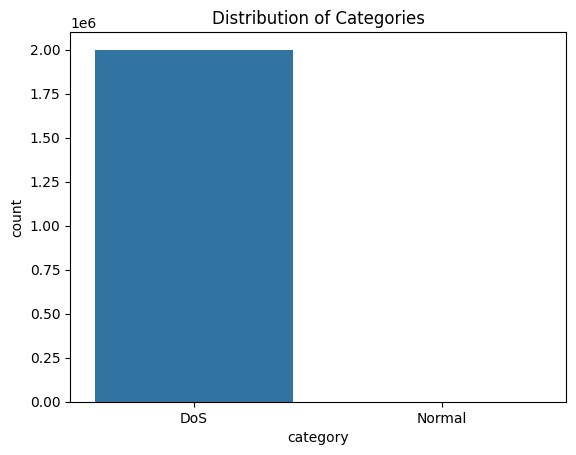

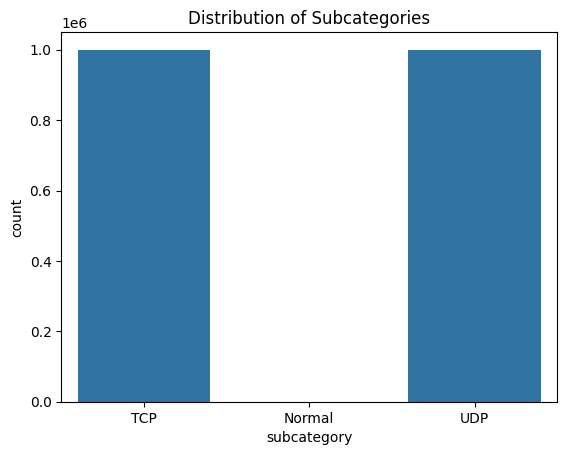

In [47]:
# Bar plot for 'attack' feature
sns.countplot(data=data, x='attack')
plt.title('Distribution of Attack Types')
plt.show()

# Bar plot for 'category' feature
sns.countplot(data=data, x='category')
plt.title('Distribution of Categories')
plt.show()

# Bar plot for 'subcategory' feature
sns.countplot(data=data, x='subcategory')
plt.title('Distribution of Subcategories')
plt.show()


In [48]:
X_train, X_test, y_train, y_test = train_test_split(ten_best_features,target_features)

In [49]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [50]:
class RandomForest:
    def __init__(self,max_depth):
        self.rfc_attack = RandomForestClassifier(max_depth=max_depth)
        self.rfc_category = RandomForestClassifier(max_depth=max_depth)
        self.rfc_subcategory = RandomForestClassifier(max_depth=max_depth)
    
    def fit(self,X_train,y_train):
        self.rfc_attack.fit(X_train,y_train['attack'])
        
        features_category = np.concatenate((X_train,np.array(y_train['attack']).reshape(-1,1)),axis=1)
        self.rfc_category.fit(features_category,y_train['category'])
        
        features_subcategory = np.concatenate((features_category,np.array(y_train['category']).reshape(-1,1)),axis=1)
        self.rfc_subcategory.fit(features_subcategory,y_train['subcategory'])
        
    def predict(self,X_test):
        predict_attack = self.rfc_attack.predict(X_test)
        
        test_category = np.concatenate((X_test,predict_attack.reshape(-1,1)),axis=1)
        predict_category = self.rfc_category.predict(test_category)
        
        test_subcategory = np.concatenate((test_category,predict_category.reshape(-1,1)),axis=1)
        predict_subcategory = self.rfc_subcategory.predict(test_subcategory)
        
        return pd.DataFrame({'attack':predict_attack,'category':predict_category,'subcategory':predict_subcategory})

In [51]:
class NaiveBayes:
    def __init__(self):
        self.nb_attack = GaussianNB()
        self.nb_category = GaussianNB()
        self.nb_subcategory = GaussianNB()
    
    def fit(self,X_train,y_train):
        self.nb_attack.fit(X_train,y_train['attack'])
        
        features_category = np.concatenate((X_train,np.array(y_train['attack']).reshape(-1,1)),axis=1)
        self.nb_category.fit(features_category,y_train['category'])
        
        features_subcategory = np.concatenate((features_category,np.array(y_train['category']).reshape(-1,1)),axis=1)
        self.nb_subcategory.fit(features_subcategory,y_train['subcategory'])
        
    def predict(self,X_test):
        predict_attack = self.nb_attack.predict(X_test)
        
        test_category = np.concatenate((X_test,predict_attack.reshape(-1,1)),axis=1)
        predict_category = self.nb_category.predict(test_category)
        
        test_subcategory = np.concatenate((test_category,predict_category.reshape(-1,1)),axis=1)
        predict_subcategory = self.nb_subcategory.predict(test_subcategory)
        
        return pd.DataFrame({'attack':predict_attack,'category':predict_category,'subcategory':predict_subcategory})

In [52]:
class DecisionTree:
    def __init__(self,criterion,max_depth=5):
        self.dtree_attack = DecisionTreeClassifier(criterion=criterion,max_depth=max_depth)
        self.dtree_category = DecisionTreeClassifier(criterion=criterion,max_depth=max_depth)
        self.dtree_subcategory = DecisionTreeClassifier(criterion=criterion,max_depth=max_depth)
    
    def fit(self,X_train,y_train):
        self.dtree_attack.fit(X_train,y_train['attack'])
        
        features_category = np.concatenate((X_train,np.array(y_train['attack']).reshape(-1,1)),axis=1)
        self.dtree_category.fit(features_category,y_train['category'])
        
        features_subcategory = np.concatenate((features_category,np.array(y_train['category']).reshape(-1,1)),axis=1)
        self.dtree_subcategory.fit(features_subcategory,y_train['subcategory'])
        
    def predict(self,X_test):
        predict_attack = self.dtree_attack.predict(X_test)
        
        test_category = np.concatenate((X_test,predict_attack.reshape(-1,1)),axis=1)
        predict_category = self.dtree_category.predict(test_category)
        
        test_subcategory = np.concatenate((test_category,predict_category.reshape(-1,1)),axis=1)
        predict_subcategory = self.dtree_subcategory.predict(test_subcategory)
        
        return pd.DataFrame({'attack':predict_attack,'category':predict_category,'subcategory':predict_subcategory})

In [53]:
class GradientBoost:
    def __init__(self):
        self.xgb_attack = XGBClassifier()
        self.xgb_category = XGBClassifier()
        self.xgb_subcategory = XGBClassifier()
    
    def fit(self,X_train,y_train):
        self.xgb_attack.fit(X_train,y_train['attack'])
        
        features_category = np.concatenate((X_train,np.array(y_train['attack']).reshape(-1,1)),axis=1)
        self.xgb_category.fit(features_category,y_train['category'])
        
        features_subcategory = np.concatenate((features_category,np.array(y_train['category']).reshape(-1,1)),axis=1)
        self.xgb_subcategory.fit(features_subcategory,y_train['subcategory'])
        
    def predict(self,X_test):
        predict_attack = self.xgb_attack.predict(X_test)
        
        test_category = np.concatenate((X_test,predict_attack.reshape(-1,1)),axis=1)
        predict_category = self.xgb_category.predict(test_category)
        
        test_subcategory = np.concatenate((test_category,predict_category.reshape(-1,1)),axis=1)
        predict_subcategory = self.xgb_subcategory.predict(test_subcategory)
        
        return pd.DataFrame({'attack':predict_attack,'category':predict_category,'subcategory':predict_subcategory})

In [54]:
rf = RandomForest(max_depth=3)
rf.fit(X_train,y_train)

predictions_rfc = rf.predict(X_test)


In [55]:
print(confusion_matrix(y_test['attack'],predictions_rfc['attack']))
print(classification_report(y_test['attack'],predictions_rfc['attack']))

[[    15      0]
 [     0 499985]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00    499985

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



In [56]:
print(confusion_matrix(y_test['category'],predictions_rfc['category']))
print(classification_report(y_test['category'],predictions_rfc['category']))

[[499985      0]
 [     0     15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    499985
           1       1.00      1.00      1.00        15

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



In [57]:
print(confusion_matrix(y_test['subcategory'],predictions_rfc['subcategory']))
print(classification_report(y_test['subcategory'],predictions_rfc['subcategory']))

[[    14      1      0]
 [     0 250205      4]
 [     0      1 249775]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       1.00      1.00      1.00    250209
           2       1.00      1.00      1.00    249776

    accuracy                           1.00    500000
   macro avg       1.00      0.98      0.99    500000
weighted avg       1.00      1.00      1.00    500000



In [58]:
rf.rfc_attack.score(X_test,y_test['attack'])

1.0

In [59]:
rf.rfc_category.score(np.concatenate((X_test,np.array(predictions_rfc['attack']).reshape(-1,1)),axis=1),y_test['category'])

1.0

In [60]:
rf.rfc_subcategory.score(np.concatenate((X_test,np.array(predictions_rfc['attack']).reshape(-1,1),
                                    np.array(predictions_rfc['category']).reshape(-1,1)),axis=1),y_test['subcategory'])

0.999988

In [62]:
nb = NaiveBayes()
nb.fit(X_train,y_train)

predictions_nb = nb.predict(X_test)

In [63]:
print(confusion_matrix(y_test['attack'],predictions_nb['attack']))
print(classification_report(y_test['attack'],predictions_nb['attack']))

[[    15      0]
 [   180 499805]]
              precision    recall  f1-score   support

           0       0.08      1.00      0.14        15
           1       1.00      1.00      1.00    499985

    accuracy                           1.00    500000
   macro avg       0.54      1.00      0.57    500000
weighted avg       1.00      1.00      1.00    500000



In [64]:
print(confusion_matrix(y_test['category'],predictions_nb['category']))
print(classification_report(y_test['category'],predictions_nb['category']))

[[499805    180]
 [     0     15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    499985
           1       0.08      1.00      0.14        15

    accuracy                           1.00    500000
   macro avg       0.54      1.00      0.57    500000
weighted avg       1.00      1.00      1.00    500000



In [65]:
print(confusion_matrix(y_test['subcategory'],predictions_nb['subcategory']))
print(classification_report(y_test['subcategory'],predictions_nb['subcategory']))

[[    15      0      0]
 [   170 250039      0]
 [    10  11860 237906]]
              precision    recall  f1-score   support

           0       0.08      1.00      0.14        15
           1       0.95      1.00      0.98    250209
           2       1.00      0.95      0.98    249776

    accuracy                           0.98    500000
   macro avg       0.68      0.98      0.70    500000
weighted avg       0.98      0.98      0.98    500000



In [66]:
dtree_ig = DecisionTree('entropy')
dtree_ig.fit(X_train,y_train)
predictions_dtree_ig = dtree_ig.predict(X_test)

In [67]:
print(confusion_matrix(y_test['attack'],predictions_dtree_ig['attack']))
print(classification_report(y_test['attack'],predictions_dtree_ig['attack']))


[[    15      0]
 [     0 499985]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00    499985

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



In [68]:
print(confusion_matrix(y_test['category'],predictions_dtree_ig['category']))
print(classification_report(y_test['category'],predictions_dtree_ig['category']))

[[499985      0]
 [     0     15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    499985
           1       1.00      1.00      1.00        15

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



In [69]:
print(confusion_matrix(y_test['subcategory'],predictions_dtree_ig['subcategory']))
print(classification_report(y_test['subcategory'],predictions_dtree_ig['subcategory']))

[[    15      0      0]
 [     0 250208      1]
 [     0      7 249769]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00    250209
           2       1.00      1.00      1.00    249776

    accuracy                           1.00    500000
   macro avg       1.00      1.00      1.00    500000
weighted avg       1.00      1.00      1.00    500000



In [70]:
dtree_ig.dtree_attack.score(X_test,y_test['attack'])

1.0

In [71]:
dtree_ig.dtree_category.score(np.concatenate((X_test,np.array(predictions_dtree_ig['attack']).reshape(-1,1)),axis=1),y_test['category'])

1.0

In [72]:
dtree_ig.dtree_subcategory.score(np.concatenate((X_test,np.array(predictions_dtree_ig['attack']).reshape(-1,1),
                                        np.array(predictions_dtree_ig['category']).reshape(-1,1)),axis=1),y_test['subcategory'])

0.999984

In [73]:
xgb = GradientBoost()
xgb.fit(X_train,y_train)
predictions_xgb = xgb.predict(X_test)


In [74]:
print(confusion_matrix(y_test['attack'],predictions_xgb['attack']))
print(classification_report(y_test['attack'],predictions_xgb['attack']))

[[    15      0]
 [     1 499984]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      1.00      1.00    499985

    accuracy                           1.00    500000
   macro avg       0.97      1.00      0.98    500000
weighted avg       1.00      1.00      1.00    500000



In [75]:
print(confusion_matrix(y_test['category'],predictions_xgb['category']))
print(classification_report(y_test['category'],predictions_xgb['category']))

[[499984      1]
 [     0     15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    499985
           1       0.94      1.00      0.97        15

    accuracy                           1.00    500000
   macro avg       0.97      1.00      0.98    500000
weighted avg       1.00      1.00      1.00    500000



In [76]:
print(confusion_matrix(y_test['subcategory'],predictions_xgb['subcategory']))
print(classification_report(y_test['subcategory'],predictions_xgb['subcategory']))

[[    15      0      0]
 [     0 250209      0]
 [     1      7 249768]]
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       1.00      1.00      1.00    250209
           2       1.00      1.00      1.00    249776

    accuracy                           1.00    500000
   macro avg       0.98      1.00      0.99    500000
weighted avg       1.00      1.00      1.00    500000



In [77]:

xgb.xgb_category.score(np.concatenate((X_test,np.array(predictions_xgb['attack']).reshape(-1,1)),axis=1),y_test['category'])
xgb.xgb_subcategory.score(np.concatenate((X_test,np.array(predictions_xgb['attack']).reshape(-1,1),
                                        np.array(predictions_xgb['category']).reshape(-1,1)),axis=1),y_test['subcategory'])

0.999984

In [78]:
xgb.xgb_attack.score(X_test,y_test['attack'])

0.999998

In [79]:
xgb.xgb_category.score(np.concatenate((X_test,np.array(predictions_xgb['attack']).reshape(-1,1)),axis=1),y_test['category'])

0.999998

# Test work to do and for that i have to combine atleast 3-4 dataset and this training part also should be added with 2-3 more dataset to randomize because giving direct answer